# Functoin Transformers

 >Basically, these are mathematical transformations that we implement on columns to make data normally distributed

***What Is Normal Distribution?***

A normal distribution is a distribution that is solely dependent on two parameters of the data set: the mean and the standard deviation of the sample.

 > * Mean — This is the average value of all the points in the sample that is computed by summing the values and then dividing by the total number of the values in a sample.

 > * Standard Deviation — This indicates how much the data set deviates from the mean of the sample.

***Function Transformer has different types to make data more normally distributed***

  >  ***1.Log transformer***
  * mostly used on right-skewed data.

  * It cannot be applied to negative data as we can't calculate the log of negative numbers
  * It helps in the accuracy of linear models as it changes the additive scale to multiplicates scale.

 > 2.Reciprocal
  * It is mostly used when we need to change small values to big values and vice versa

> 3.Square
 * Mostly used in left-skewed data

| Algorithm            | Need Transformation? | Why                           |
| -------------------- | -------------------- | ----------------------------- |
| Linear Regression    | YES                  | Assumes linearity & normality |
| Logistic Regression  | YES                  | Linear decision boundary      |
| Gaussian Naive Bayes | YES                  | Assumes Gaussian distribution |
| PCA                  | YES                  | Variance-sensitive            |
| LDA/QDA              | YES                  | Gaussian assumption           |
| SVM                  | SOMETIMES            | Sensitive to outliers         |
| KNN                  | SOMETIMES            | Distance-based                |
| Neural Network       | SOMETIMES            | Helps optimization            |
| Decision Tree        | NO                   | Split-based                   |
| Random Forest        | NO                   | Tree-based                    |
| XGBoost              | NO                   | Robust to skewness            |
| LightGBM             | NO                   | Tree boosting                 |
| CatBoost             | NO                   | Tree boosting                 |


# **Square transformation**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats
from sklearn.preprocessing import FunctionTransformer

In [2]:
df = pd.read_csv('/content/sample_data/placement.csv')
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


## check skewness

In [16]:
df['placement_exam_marks'].skew()

np.float64(-0.5807076610569059)

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

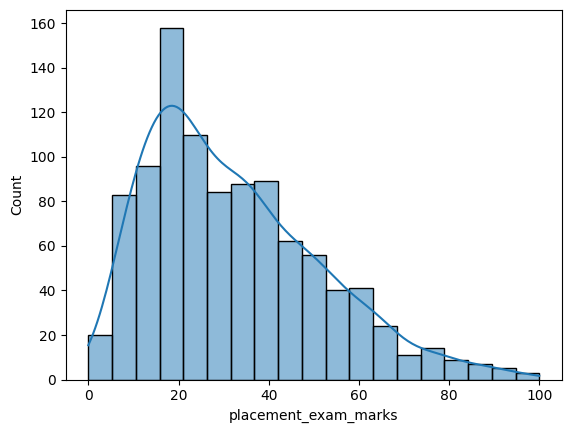

In [5]:
sns.histplot(df['placement_exam_marks'],kde=True)

 > ***The data is rightly skewed but i applied log transform before square transformations. log transform behaves aggressive and made skewed in left , so in this right skewed dataset square transform worked well !***

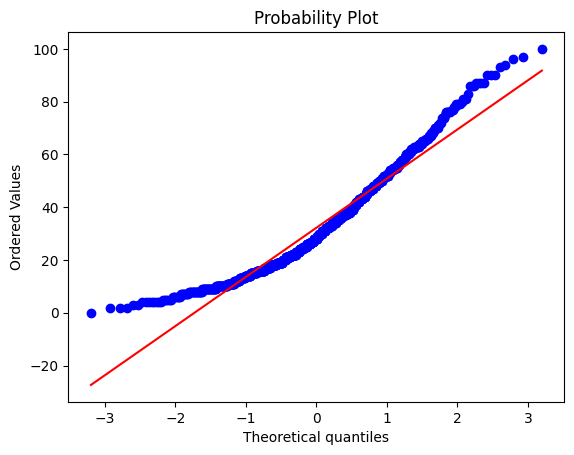

In [6]:
stats.probplot(df['placement_exam_marks'], dist='norm', plot=plt)
plt.show()

 > **If points are far from the straight line → data is skewed.**

## apply transform

In [18]:
df['square'] = df['placement_exam_marks'] ** 2

In [20]:
df['square'].skew()

np.float64(-0.01443852816769439)

<Axes: xlabel='square', ylabel='Count'>

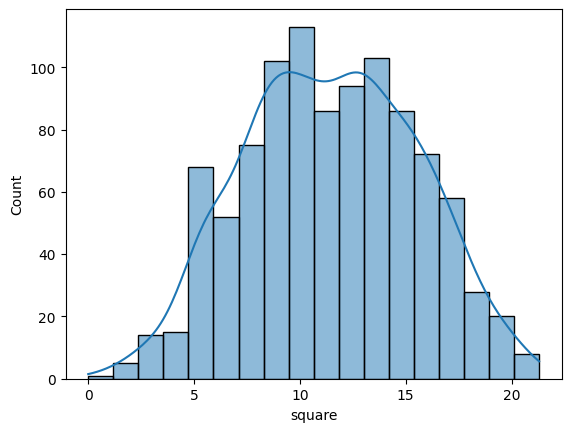

In [21]:
sns.histplot(df['square'],kde=True)

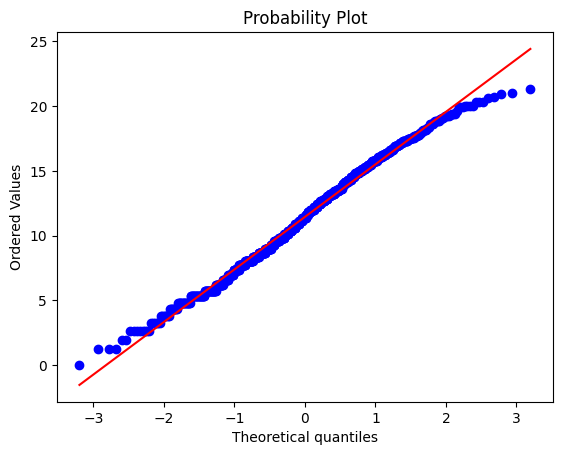

In [22]:
stats.probplot(df['square'], dist='norm', plot=plt)
plt.show()

# Log transformations

In [23]:
df = pd.read_csv('/content/sample_data/cancer_dataset_log_transform.csv')
df

,Tumor_Size_mm,Biomarker_Level,Treatment_Cost_USD,Cancer_Stage
0,36.50,30.76,26350.08,Stage III
1,21.96,82.22,14906.62,Stage IV
2,41.19,3.01,5279.34,Stage IV
3,82.97,21.39,2261.26,Stage III
4,20.34,6.36,11360.16,Stage I
...,...,...,...,...
495,37.76,9.20,54573.92,Stage I
496,10.70,73.53,58326.06,Stage II
497,21.07,23.12,20953.05,Stage IV
498,12.18,6.88,16795.65,Stage II


## check skewness

In [29]:
df['Biomarker_Level'].skew()

np.float64(3.079249902130556)

<Axes: xlabel='Biomarker_Level', ylabel='Count'>

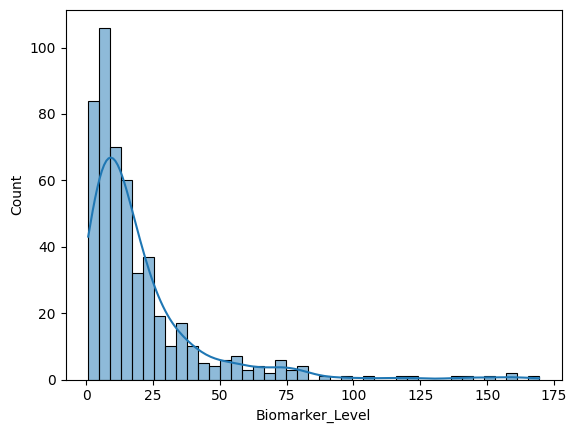

In [24]:
sns.histplot(df['Biomarker_Level'],kde=True)

In [30]:
df['Tumor_Size_mm'].skew()

np.float64(6.196718044302165)

<Axes: xlabel='Tumor_Size_mm', ylabel='Count'>

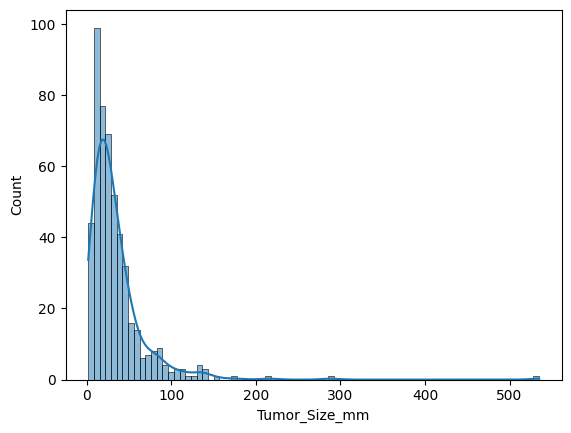

In [25]:
sns.histplot(df['Tumor_Size_mm'],kde=True)

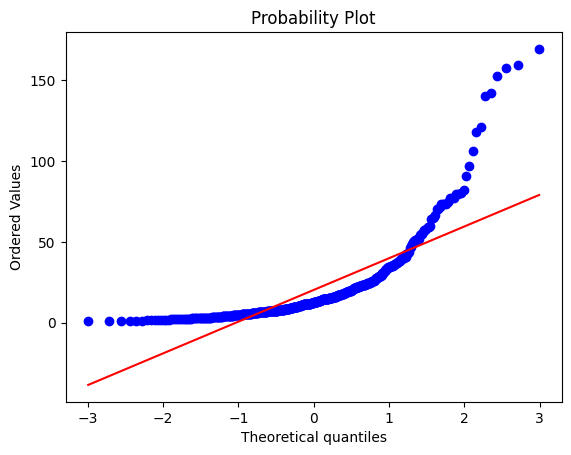

In [26]:
stats.probplot(df['Biomarker_Level'], dist='norm', plot=plt)
plt.show()

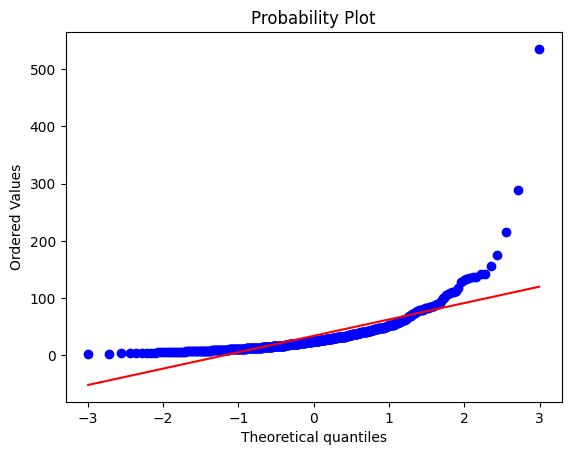

In [28]:
stats.probplot(df['Tumor_Size_mm'], dist='norm', plot=plt)
plt.show()

> *Here df['Biomarker_Level'],df['Tumor_Size_mm'] are extremely right skewed so we will apply log Transform here*

## apply transform

In [32]:
df['Biomarker_Level_log'] = np.log(df['Biomarker_Level'] + 1 )

In [33]:
df['Biomarker_Level_log'].skew()

np.float64(0.28841498357236545)

<Axes: xlabel='Biomarker_Level_log', ylabel='Count'>

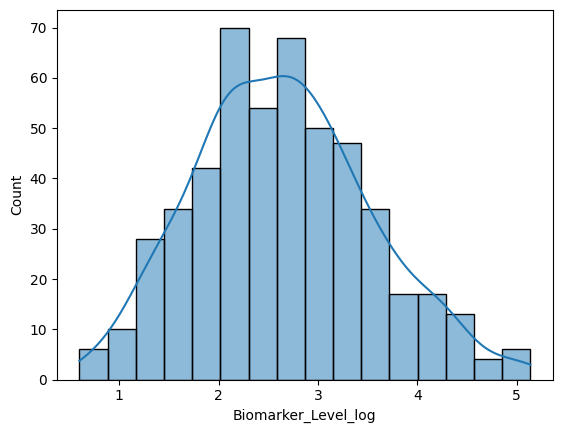

In [34]:
sns.histplot(df['Biomarker_Level_log'],kde=True)

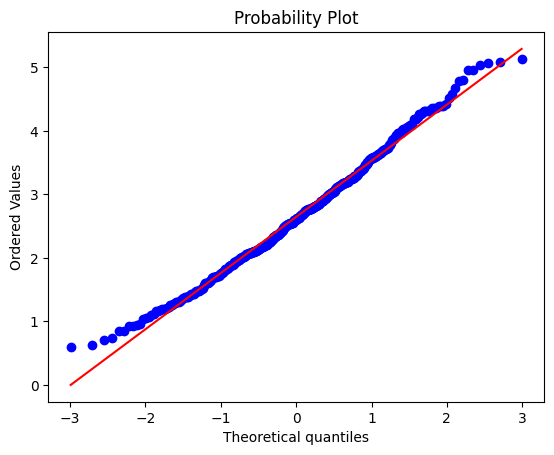

In [39]:
stats.probplot(df['Biomarker_Level_log'], dist='norm', plot=plt)
plt.show()

> -------------------------

In [36]:
df['Tumor_Size_mm_log'] = np.log(df['Tumor_Size_mm'] + 1 )

In [37]:
df['Tumor_Size_mm_log'].skew()

np.float64(0.2910051230676449)

<Axes: xlabel='Tumor_Size_mm_log', ylabel='Count'>

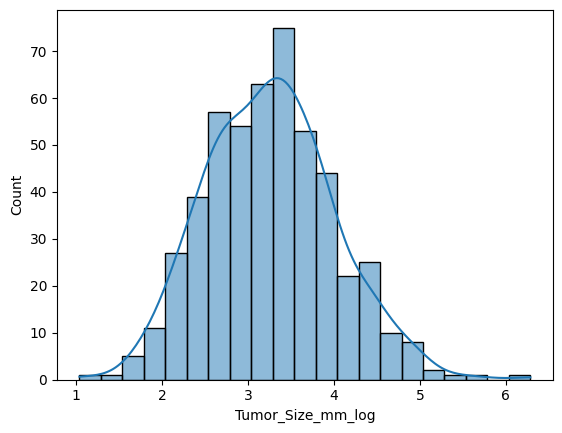

In [38]:
sns.histplot(df['Tumor_Size_mm_log'],kde=True)

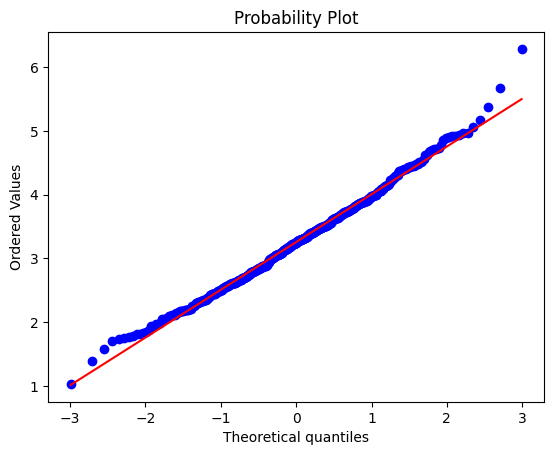

In [40]:
stats.probplot(df['Tumor_Size_mm_log'], dist='norm', plot=plt)
plt.show()